# Exploratory Data Analysis — AI Incidents Dataset

Source file: `data/incidents_data.xlsx` (AIAAIC-style repository of AI/algorithmic incidents).

The raw spreadsheet has a 3-row hierarchical header (top-level category + sub-category for the "Impacted area" and "External harm" groups). We load it with `header=None`, reconstruct flat column names, and then explore the cleaned table.

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_PATH = os.path.join('..', 'data', 'incidents_data.xlsx')

## 1. Load and reconstruct the flat header

Row 1 holds the main column names (e.g. `Impacted area`, `External harm (taxonomy)`), and row 2 holds sub-category names that only apply to those two grouped sections (`Jurisdiction`/`Sector` and `Individual`/`Societal`/`Environmental`). We forward-fill the main name and join it with the sub-name where present.

In [16]:
raw = pd.read_excel(DATA_PATH, header=None)

main_row, sub_row = raw.iloc[1].tolist(), raw.iloc[2].tolist()

columns = []
current_main = None
for main, sub in zip(main_row, sub_row):
    main = main.strip() if isinstance(main, str) else None
    sub = sub.strip() if isinstance(sub, str) else None
    if main is not None:
        current_main = main
    columns.append(f'{current_main} - {sub}' if sub is not None else current_main)

df = raw.iloc[3:].reset_index(drop=True)
df.columns = columns

# The trailing duplicate 'Summary/links' column carries a single stray URL and adds no information
df = df.drop(columns=df.columns[-1])

print(f'Shape: {df.shape[0]} incidents x {df.shape[1]} columns')
df.head()

Shape: 2251 incidents x 17 columns


,AIAAIC ID#,Headline,Occurred,Deployer,Developer,System name,Technology,Purpose,News trigger (taxonomy),Ethical issue (taxonomy),Impacted area - Jurisdiction,Impacted area - Sector,External harm (taxonomy) - Individual,External harm (taxonomy) - Societal,External harm (taxonomy) - Environmental,Consequence (taxonomy),Response (taxonomy)
0,AIAAIC2264,Meta captures employee mouse movements to trai...,2026,NaN,Meta,NaN,Agentic AI; Generative AI,Train AI models,Media investigation,Consent; Employment/labour; Normalisation; Pri...,USA,Technology,NaN,Anxiety/distress; Chilling effect; Financial l...,NaN,Employee backlash,System review/update
1,AIAAIC2263,Chinese AI actors spark personality rights con...,2026,Youhug Media,NaN,NaN,Generative AI,Create AI-generated performers,Company statement,Accountability; Consent; Employment/labour; Tr...,China,Media/entertainment/sports/arts,NaN,Financial loss; Jobs loss/losses; Misappropria...,NaN,NaN,NaN
2,AIAAIC2262,German TV star accuses husband of spreading de...,2024,Christian Ulmen,NaN,NaN,Deepfake,Harass ex-wife,Legal threat/action,Accountability; Authenticity/integrity; Privac...,Germany; Spain,Media/entertainment/sports/arts,Anxiety/distress; Privacy loss; Reputational d...,NaN,NaN,Legal complaint/investigation; Legislation int...,NaN
3,AIAAIC2261,AI chatbots lure vulnerable gamblers to unlice...,2026,NaN,Anthropic; Google; Meta; Microsoft; Mistral; O...,ChatGPT; Claude; Copilot; Gemini; Grok; Le Cha...,Generative AI,Recommend online casinos,Media investigation,Accountability; Safety; Transparency,Austria; Belgium; France; Germany; Greece; Ita...,Gambling,NaN,Financial loss; Fraud,NaN,NaN,NaN
4,AIAAIC2260,ChatGPT accused of enabling Florida State Univ...,2025,Phoenix Ikner,OpenAI,ChatGPT,Generative AI,Plan mass shooting,Legal threat/action,Accountability; Alignment; Safety,Florida,Education,NaN,Anxiety/distress; Bodily injury; Loss of life;...,NaN,Litigation,NaN


## 2. Schema overview

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2251 entries, 0 to 2250
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   AIAAIC ID#                                2250 non-null   object
 1   Headline                                  2249 non-null   object
 2   Occurred                                  2080 non-null   object
 3   Deployer                                  1684 non-null   object
 4   Developer                                 1919 non-null   object
 5   System name                               1667 non-null   object
 6   Technology                                2199 non-null   object
 7   Purpose                                   2230 non-null   object
 8   News trigger (taxonomy)                   1960 non-null   object
 9   Ethical issue (taxonomy)                  2241 non-null   object
 10  Impacted area - Jurisdiction              2244 n

In [18]:
df.dtypes.to_frame('dtype')

,dtype
AIAAIC ID#,object
Headline,object
Occurred,object
Deployer,object
Developer,object
System name,object
Technology,object
Purpose,object
News trigger (taxonomy),object
Ethical issue (taxonomy),object


## 3. Missing values

Many columns are free-text taxonomy fields that are only filled in when applicable (e.g. an incident may not cause environmental harm), so high missingness in those columns reflects the nature of the data rather than data-quality issues.

In [19]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)
missing

,missing_count,missing_pct
External harm (taxonomy) - Environmental,2214,98.4
Response (taxonomy),1773,78.8
Consequence (taxonomy),1671,74.2
External harm (taxonomy) - Individual,1440,64.0
External harm (taxonomy) - Societal,1352,60.1
System name,584,25.9
Deployer,567,25.2
Developer,332,14.7
News trigger (taxonomy),291,12.9
Occurred,171,7.6


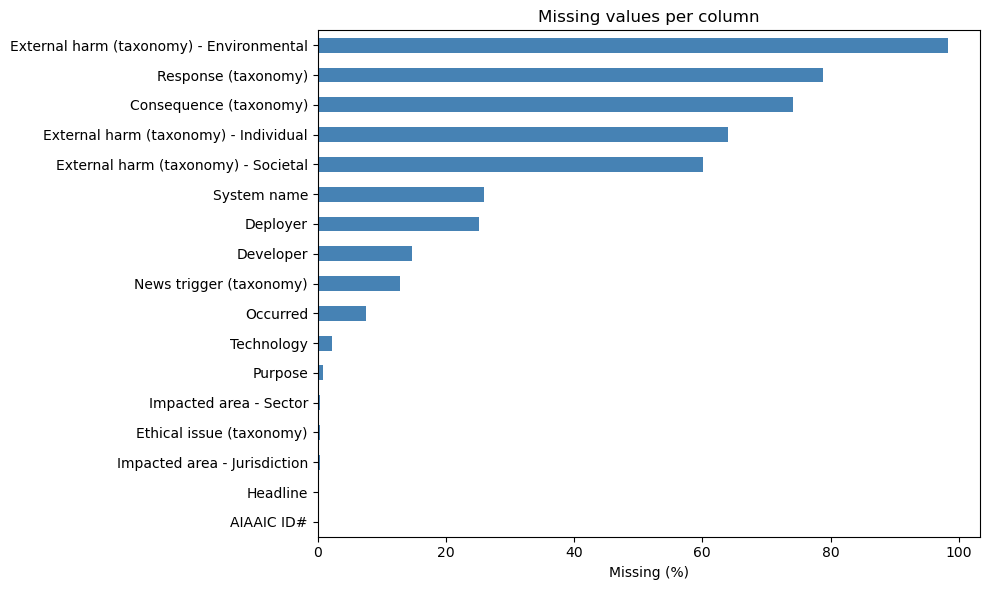

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
missing['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values per column')
plt.tight_layout()
plt.show()

## 4. Duplicates and ID integrity

In [21]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated AIAAIC IDs:', df['AIAAIC ID#'].duplicated().sum())
print('Rows with missing AIAAIC ID:', df['AIAAIC ID#'].isna().sum())
print('Rows with missing Headline:', df['Headline'].isna().sum())

Fully duplicated rows: 0
Duplicated AIAAIC IDs: 1
Rows with missing AIAAIC ID: 1
Rows with missing Headline: 2


## 5. `Occurred` (year) — cleaning and distribution

The column mixes single years (`2024`), trailing-dash years (`'2018-'`), and year ranges (`'2019-2024'`). We parse out the **start year** of each entry to build a consistent numeric timeline.

In [22]:
occurred_raw = df['Occurred'].astype(str)
start_year = occurred_raw.str.extract(r'(\d{4})')[0]
df['Occurred_start_year'] = pd.to_numeric(start_year, errors='coerce')

print('Distinct raw values (sample):')
print(sorted(df['Occurred'].dropna().astype(str).unique(), reverse=True)[:15])
print()
print('Parsed start-year range:', df['Occurred_start_year'].min(), '-', df['Occurred_start_year'].max())

Distinct raw values (sample):
['2026', '2025', '2024', '2023-2024', '2023-', '2023', '2022-2024', '2022-', '2022', '2021', '2020-2021', '2020-', '2020', '2019-2024', '2019']

Parsed start-year range: 2008.0 - 2026.0


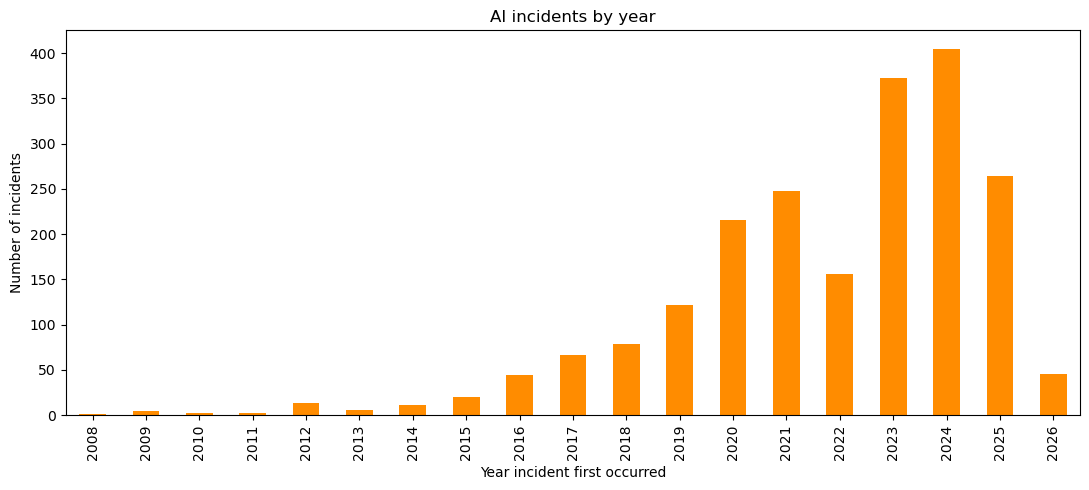

In [23]:
year_counts = df['Occurred_start_year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
year_counts.plot(kind='bar', ax=ax, color='darkorange')
ax.set_xlabel('Year incident first occurred')
ax.set_ylabel('Number of incidents')
ax.set_title('AI incidents by year')
plt.tight_layout()
plt.show()

## 6. Top deployers, developers and systems

These are free-text organisation fields — counts reflect the most frequently *named* entities in incident reports, not a comprehensive ranking.

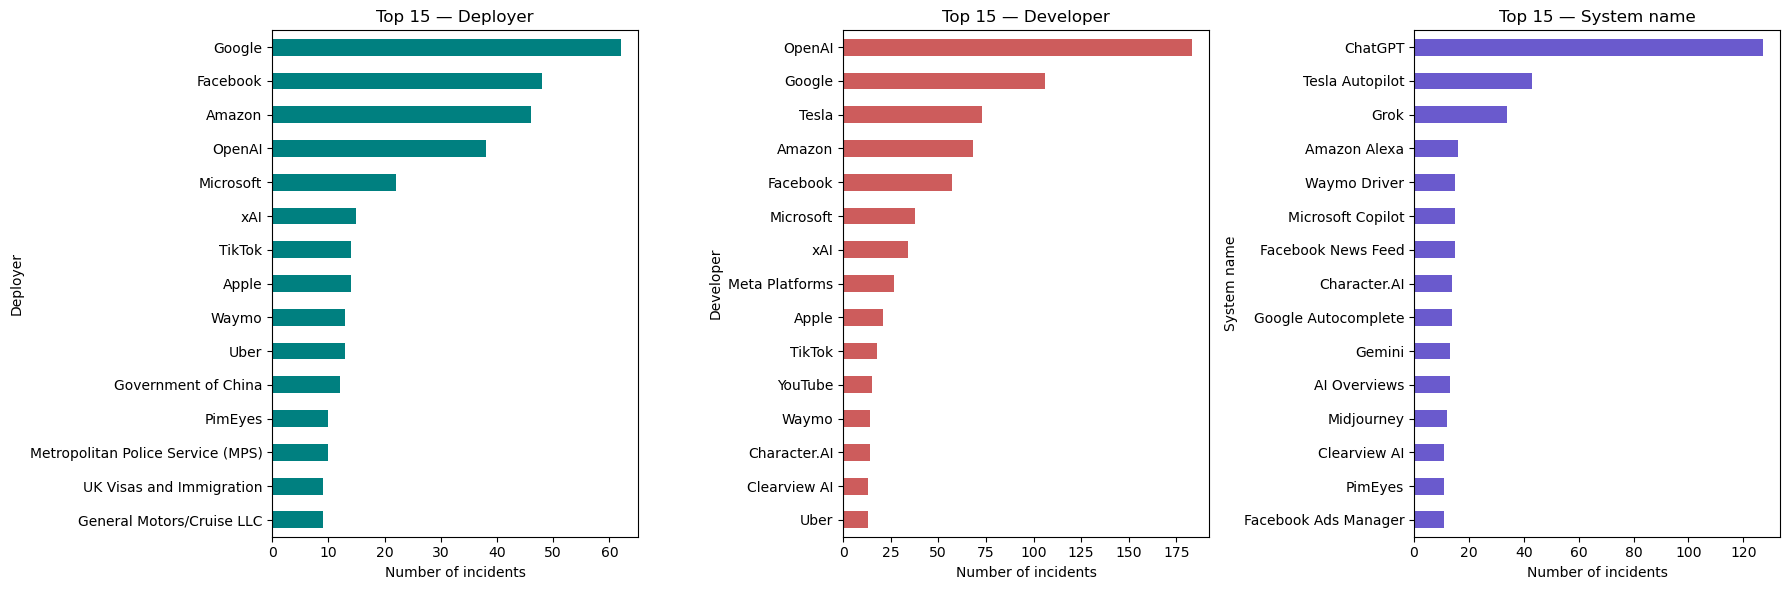

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, color in zip(axes, ['Deployer', 'Developer', 'System name'], ['teal', 'indianred', 'slateblue']):
    top = df[col].value_counts().head(15)
    top.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Top 15 — {col}')
    ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

## 7. Multi-valued taxonomy columns

Several columns (`Technology`, `Ethical issue (taxonomy)`, `External harm ...`, `Consequence (taxonomy)`, `Response (taxonomy)`, etc.) pack multiple semicolon-separated tags into a single cell. We split and explode these to count individual tag frequencies.

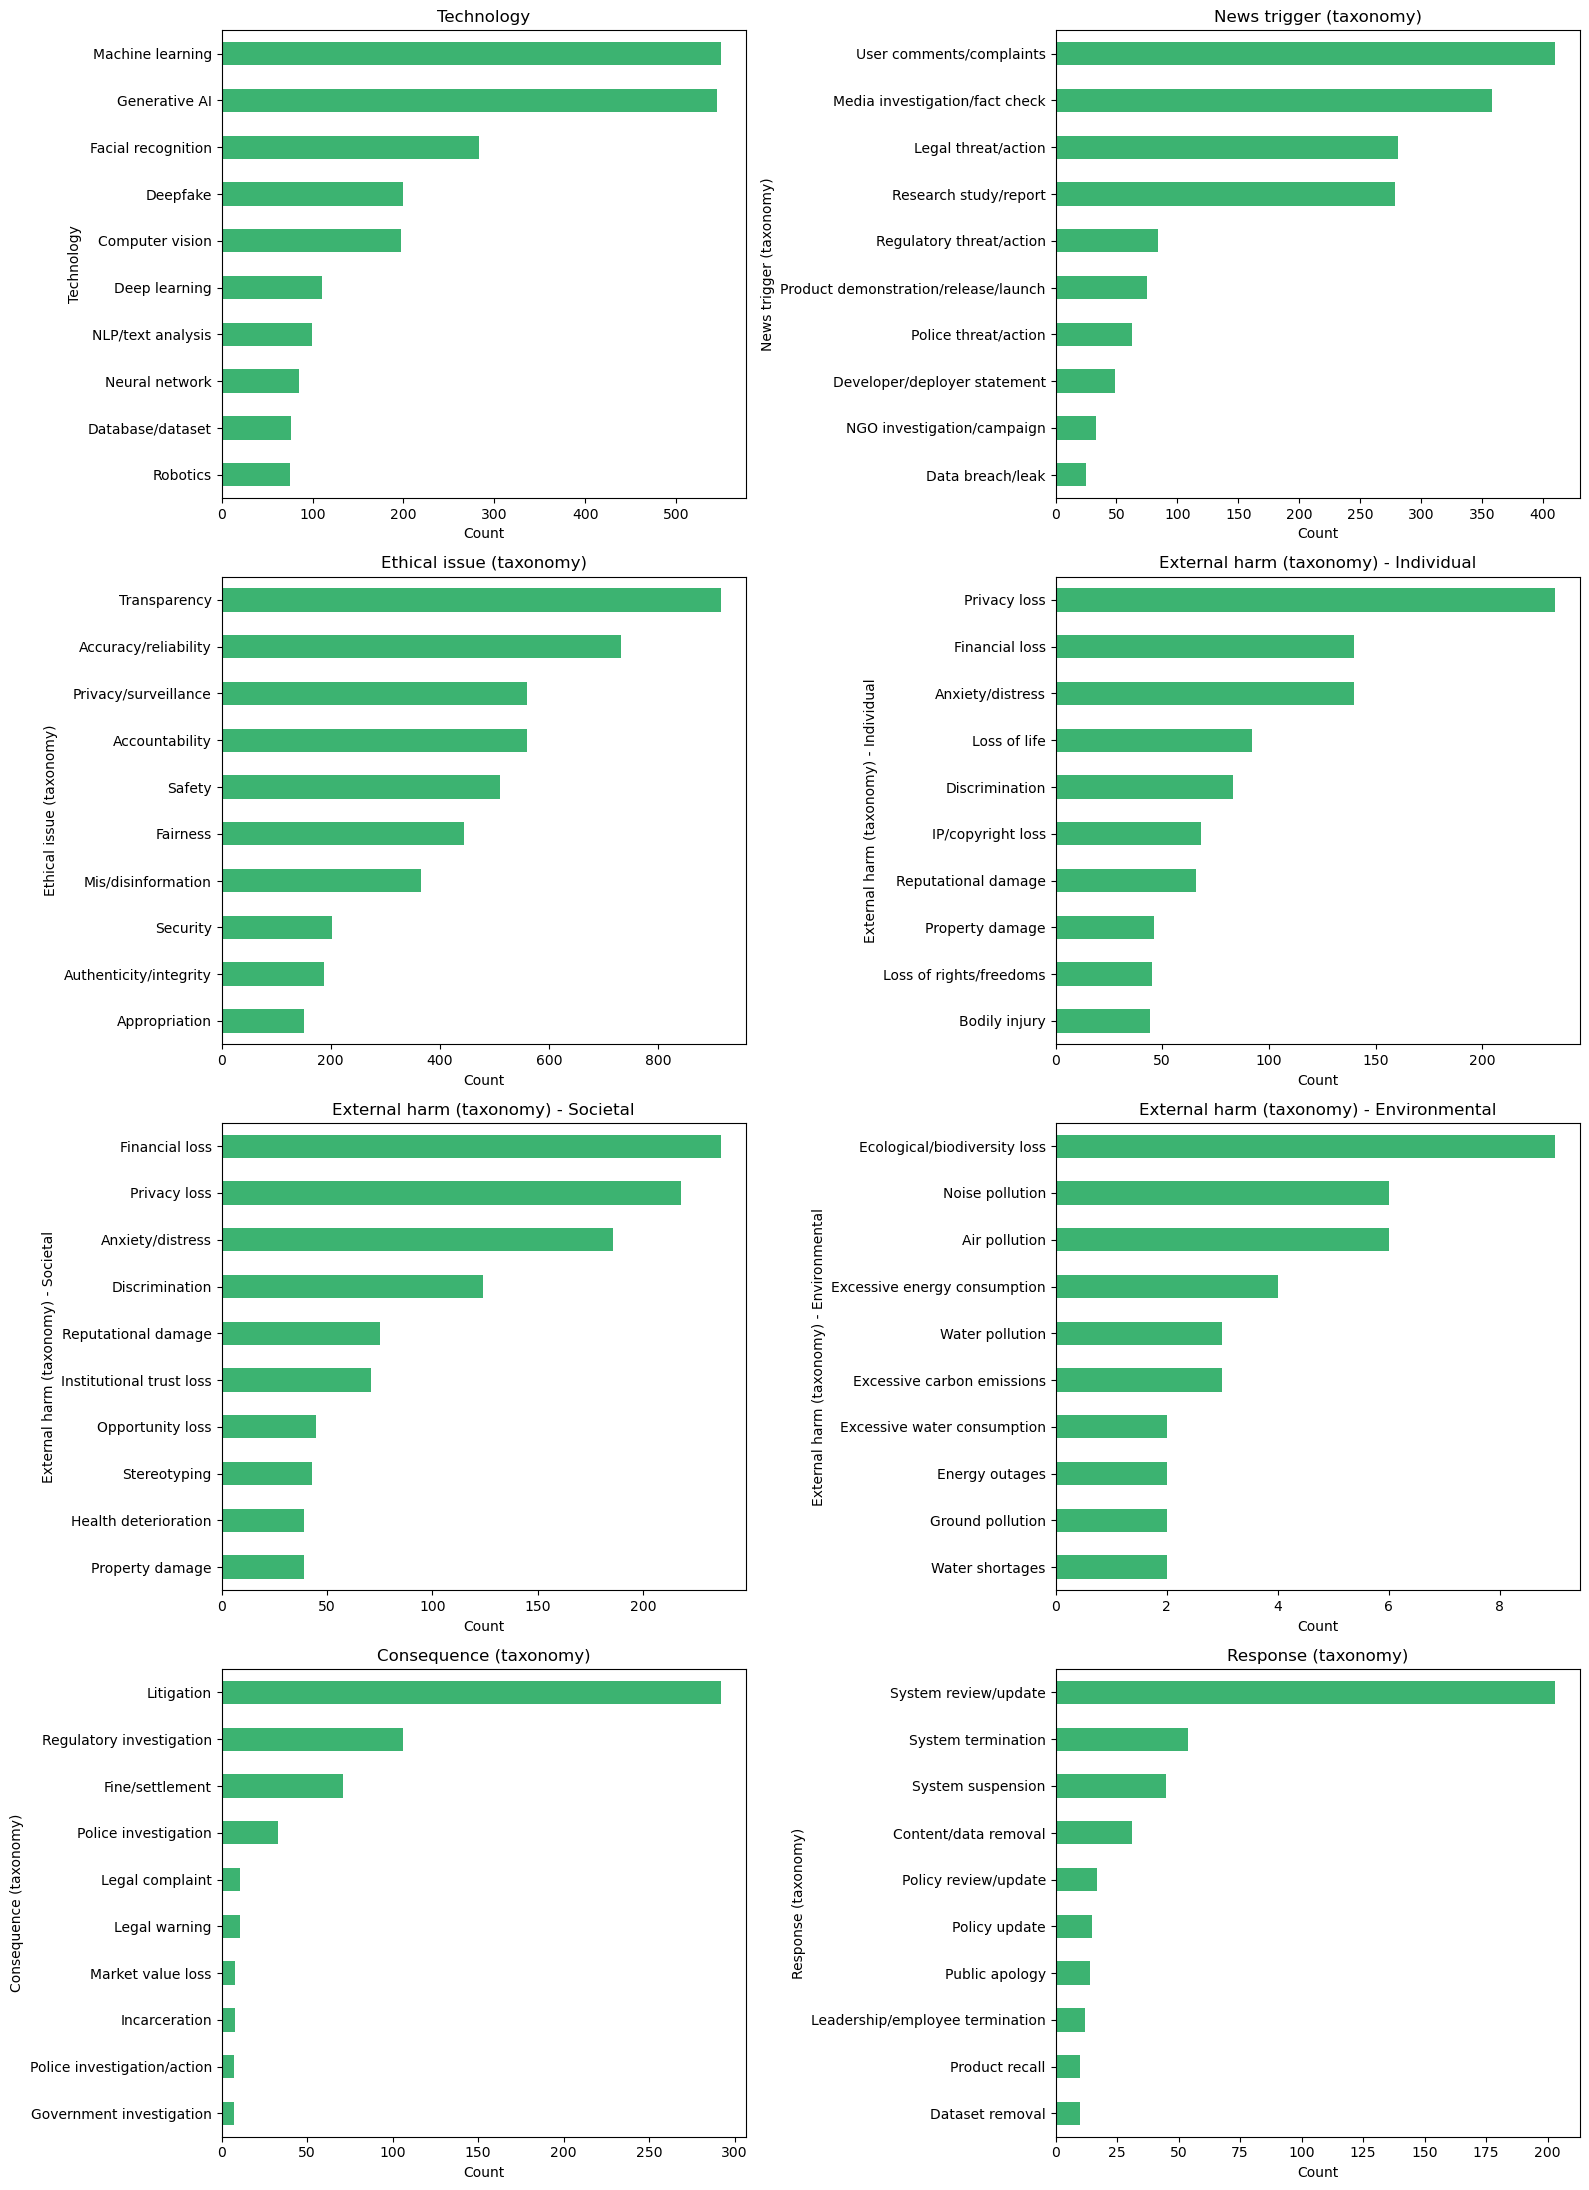

In [25]:
def explode_tags(series):
    """Split semicolon-separated tag strings into a flat Series of individual tags."""
    return (
        series.dropna()
        .str.split(';')
        .explode()
        .str.strip()
        .replace('', np.nan)
        .dropna()
    )

tag_columns = [
    'Technology',
    'News trigger (taxonomy)',
    'Ethical issue (taxonomy)',
    'External harm (taxonomy) - Individual',
    'External harm (taxonomy) - Societal',
    'External harm (taxonomy) - Environmental',
    'Consequence (taxonomy)',
    'Response (taxonomy)',
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
for ax, col in zip(axes.flat, tag_columns):
    counts = explode_tags(df[col]).value_counts().head(10)
    counts.sort_values().plot(kind='barh', ax=ax, color='mediumseagreen')
    ax.set_title(col)
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 8. Geography: jurisdictions and sectors

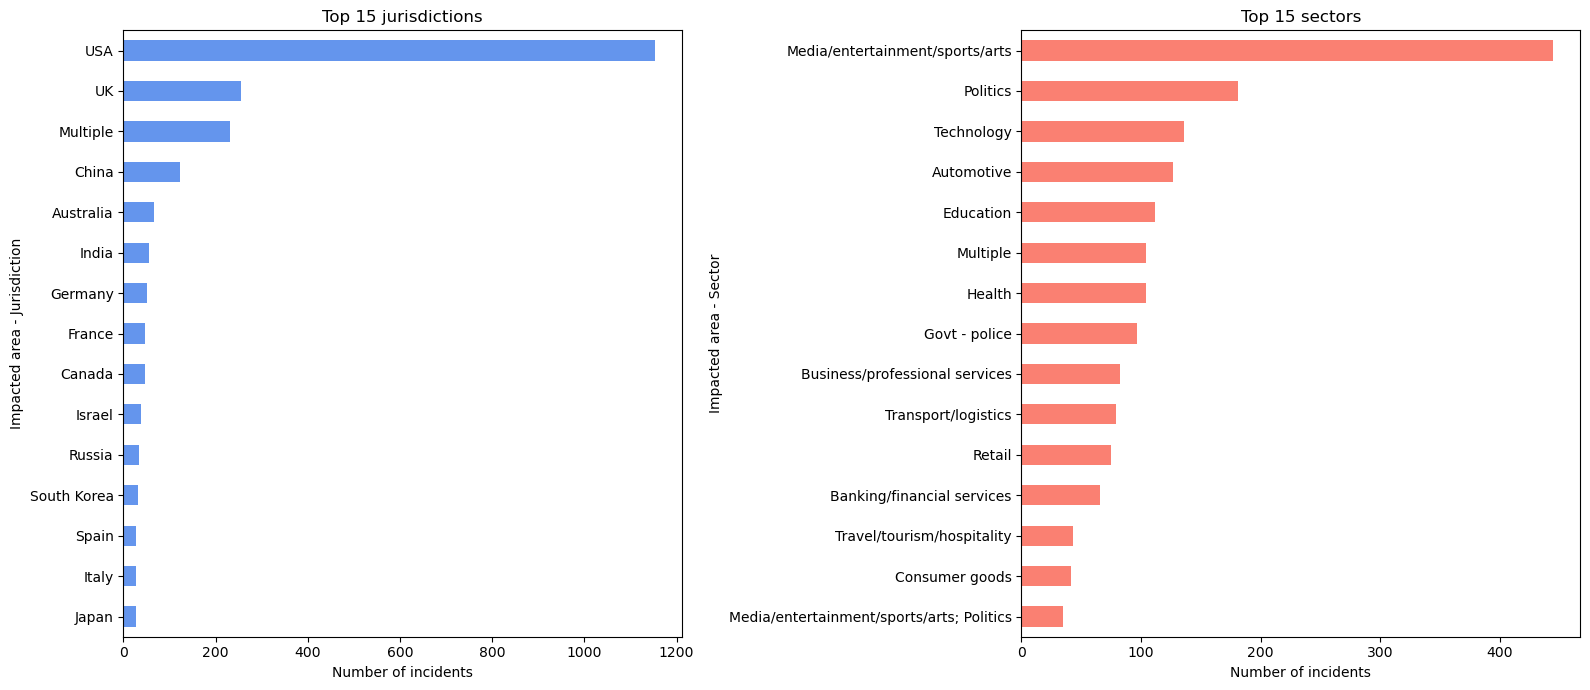

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

explode_tags(df['Impacted area - Jurisdiction']).value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Top 15 jurisdictions')
axes[0].set_xlabel('Number of incidents')

df['Impacted area - Sector'].value_counts().head(15).sort_values().plot(
    kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 15 sectors')
axes[1].set_xlabel('Number of incidents')

plt.tight_layout()
plt.show()

## 9. Purpose of the AI system

Free-text field describing *why* the system was deployed (e.g. "Train AI models", "Generate images"). We look at the most common stated purposes.

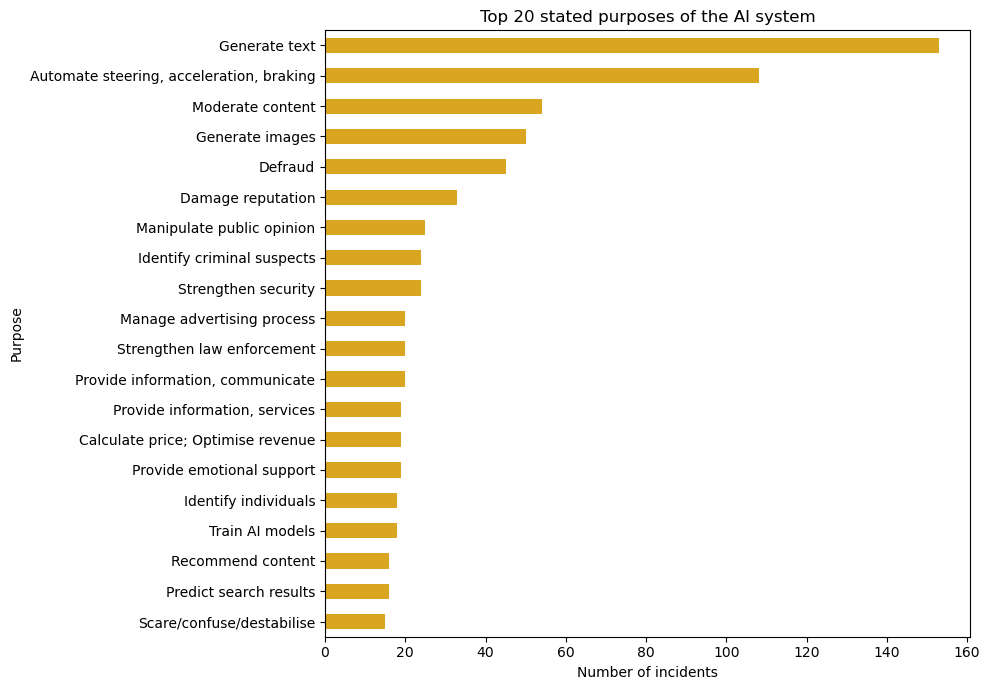

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))
df['Purpose'].value_counts().head(20).sort_values().plot(kind='barh', ax=ax, color='goldenrod')
ax.set_title('Top 20 stated purposes of the AI system')
ax.set_xlabel('Number of incidents')
plt.tight_layout()
plt.show()

## 10. Ethical issues over time

How have the most common ethical-issue tags trended across years? We look at the five most frequent tags overall and chart their counts per year.

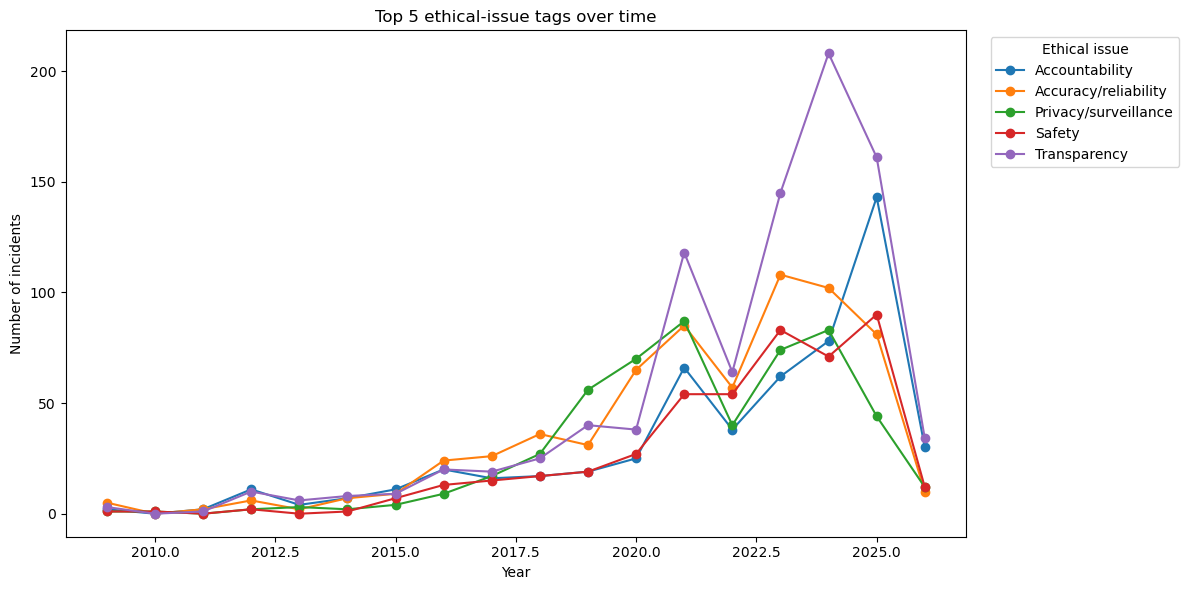

In [28]:
issues_exploded = (
    df[['Occurred_start_year', 'Ethical issue (taxonomy)']]
    .dropna()
    .assign(issue=lambda d: d['Ethical issue (taxonomy)'].str.split(';'))
    .explode('issue')
    .assign(issue=lambda d: d['issue'].str.strip())
)

top5_issues = issues_exploded['issue'].value_counts().head(5).index
pivot = (
    issues_exploded[issues_exploded['issue'].isin(top5_issues)]
    .groupby(['Occurred_start_year', 'issue'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(ax=ax, marker='o')
ax.set_title('Top 5 ethical-issue tags over time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of incidents')
ax.legend(title='Ethical issue', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 11. Summary of key observations

- **Size**: ~2,251 cataloged AI incidents spanning roughly 2009–2026, with most concentrated in the last few years (data collection/reporting growth, not necessarily incident-rate growth).
- **Sparsity is structural**: fields like `External harm - Environmental`, `Consequence`, and `Response` are mostly empty (>70% missing) because they only apply to a subset of incidents — this is expected for a taxonomy-style incident log, not a data-quality defect.
- **`Occurred` needs cleaning**: the field mixes single years, open-ended ranges (`'2018-'`), and closed ranges (`'2019-2024'`); we extracted a `Occurred_start_year` for any time-based analysis.
- **Multi-label taxonomy fields**: `Technology`, `Ethical issue`, `External harm`, `Consequence`, and `Response` are semicolon-delimited multi-tag strings and must be exploded before counting — a single incident commonly carries several tags.
- **Geography & sector**: incidents skew toward a handful of major jurisdictions (e.g. USA) and a few dominant sectors (e.g. Technology, Media/entertainment), which likely reflects reporting bias as much as actual incident distribution.
- **Entities**: `Deployer`, `Developer`, and `System name` have high missingness (15–26%) — many incidents are reported without full attribution, which should be considered when doing any organisation-level aggregation.